# 06 Deep Learning Model

This notebook contains the deep learning experiment from the original project.

The original code cells are preserved. Only Markdown section titles and explanations have been added for GitHub readability.


## 1. Deep Learning Model Preparation and Training

This section prepares the modelling data, builds the neural network model, and trains it.


In [ ]:

# create DNN modelling
model = Sequential()

# add lyer
model.add(Dense(128, input_dim=X_train_resampled.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout reduce overfitting
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# output
model.add(Dense(5, activation='softmax'))

# pragram modelling
optimizer = Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training model
model.fit(X_train_resampled, y_train_resampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50


C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2473/2473 ━━━━━━━━━━━━━━━━━━━━ 3s 755us/step - accuracy: 0.2950 - loss: 1.5160 - val_accuracy: 0.3477 - val_loss: 1.4589
Epoch 2/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 702us/step - accuracy: 0.3131 - loss: 1.4859 - val_accuracy: 0.4063 - val_loss: 1.4467
Epoch 3/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 705us/step - accuracy: 0.3156 - loss: 1.4831 - val_accuracy: 0.3602 - val_loss: 1.4499
Epoch 4/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 700us/step - accuracy: 0.3150 - loss: 1.4812 - val_accuracy: 0.3811 - val_loss: 1.4578
Epoch 5/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 712us/step - accuracy: 0.3164 - loss: 1.4789 - val_accuracy: 0.4017 - val_loss: 1.4429
Epoch 6/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 695us/step - accuracy: 0.3180 - loss: 1.4777 - val_accuracy: 0.3545 - val_loss: 1.4629
Epoch 7/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 703us/step - accuracy: 0.3185 - loss: 1.4774 - val_accuracy: 0.3858 - val_loss: 1.4395
Epoch 8/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 704us/step - accuracy: 0.3206 - loss: 1.47

## 2. Model Evaluation

This section evaluates the trained deep learning model and prints the model performance.


In [ ]:

model = Sequential()
model.add(Dense(256, input_dim=X_train.shape[1], activation='relu')) 
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))  
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(5, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.3f}")


637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.1012 - loss: 1.6165
Test accuracy: 0.102


## 3. Additional Deep Learning / Experimental Cell

This section preserves the additional original deep learning experiment cell.


In [ ]:
print(df_cd.columns)

Index(['Crash_Ref_Number', 'Crash_Severity', 'Crash_Year', 'Crash_Month',
       'Crash_Day_Of_Week', 'Crash_Hour', 'Crash_Nature', 'Crash_Type',
       'Crash_Longitude', 'Crash_Latitude', 'Crash_Street',
       'Crash_Street_Intersecting', 'State_Road_Name', 'Loc_Suburb',
       'Loc_Local_Government_Area', 'Loc_Post_Code', 'Loc_Police_Division',
       'Loc_Police_District', 'Loc_Police_Region',
       'Loc_Queensland_Transport_Region', 'Loc_Main_Roads_Region',
       'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3',
       'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness',
       'Loc_State_Electorate', 'Loc_Federal_Electorate',
       'Crash_Controlling_Authority', 'Crash_Roadway_Feature',
       'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_De

## 4. Additional Evaluation / Output Cell

This section preserves the additional original evaluation or output cell.


Number of clusters: 8
Silhouette Score: 0.600


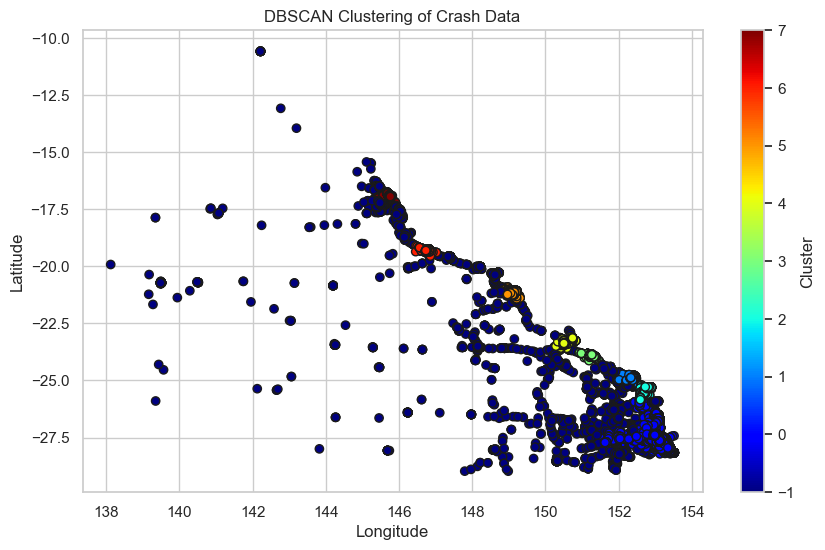

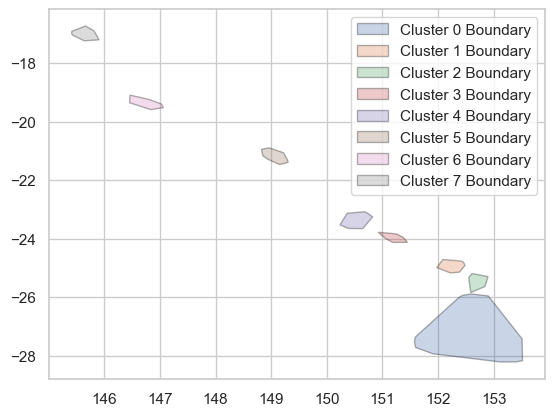

In [ ]:

# use combined dataset
df = df_cd
# select latitude and longitude be the feture
coords = df[['Latitude', 'Longitude']].values
# DBSCAN clustering
epsilon = 20/ 6371.0088  # 0.1km
db = DBSCAN(eps=epsilon, min_samples=500, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
# result output
labels = db.labels_
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Number of clusters: {num_clusters}')



df['Cluster'] = labels
# modeling evaluation
# 1. silhouette score
if len(set(labels)) > 1:  # more than 1 labels
    silhouette_avg = silhouette_score(np.radians(coords), labels)
    print(f'Silhouette Score: {silhouette_avg:.3f}')
# visualize
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Cluster'], cmap='jet', marker='o', edgecolor='k')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('DBSCAN Clustering of Crash Data')
plt.colorbar(label='Cluster')
plt.show()
unique_labels = set(labels)
for label in unique_labels:
    if label == -1:
        continue
    
    # get all the point
    cluster_points = df[df['Cluster'] == label][['Longitude', 'Latitude']].values
    if len(cluster_points) >= 3:  # at least point
        # calculate
        hull = MultiPoint([tuple(point) for point in cluster_points]).convex_hull
        # draw the diagram
        if hull.geom_type == 'Polygon':
            x, y = hull.exterior.xy
            plt.fill(x, y, alpha=0.3, edgecolor='black', linewidth=1, label=f'Cluster {label} Boundary')

plt.legend(loc='upper right')
plt.show()

## Summary

This notebook preserves the original deep learning experiment as a supplementary modelling section.

For the GitHub project, Random Forest, SVM and DBSCAN remain the main modelling components, while this notebook can be presented as an additional experiment.
